In [1]:
import pandas as pd
import numpy as np


Data Files Loading and Data Cleaning

In [3]:
# Load CSV files
orders = pd.read_csv('E:\Dissertation Sem\Papers for dissertation\orders.csv')
order_prior = pd.read_csv('E:\Dissertation Sem\Papers for dissertation\order_products__prior.csv')
order_train = pd.read_csv('E:\Dissertation Sem\Papers for dissertation\order_products__train.csv')
products = pd.read_csv('E:\Dissertation Sem\Papers for dissertation\products.csv')
aisles = pd.read_csv('E:\\Dissertation Sem\\Papers for dissertation\\aisles.csv')
departments = pd.read_csv('E:\Dissertation Sem\Papers for dissertation\departments.csv')

# Merge prior and train order-product data (all purchases)
order_products = pd.concat([order_prior, order_train], ignore_index=True)
# Merge product details
order_products = order_products.merge(products, on='product_id', how='left')
order_products = order_products.merge(aisles, on='aisle_id', how='left')
order_products = order_products.merge(departments, on='department_id', how='left')
# Merge user and order info
order_products = order_products.merge(orders[['order_id','user_id','order_number','order_dow',
                                             'order_hour_of_day','days_since_prior_order']],
                                      on='order_id', how='left')
print(order_products.head(5))

   order_id  product_id  add_to_cart_order  reordered           product_name  \
0         2       33120                  1          1     Organic Egg Whites   
1         2       28985                  2          1  Michigan Organic Kale   
2         2        9327                  3          0          Garlic Powder   
3         2       45918                  4          1         Coconut Butter   
4         2       30035                  5          0      Natural Sweetener   

   aisle_id  department_id               aisle  department  user_id  \
0        86             16                eggs  dairy eggs   202279   
1        83              4    fresh vegetables     produce   202279   
2       104             13   spices seasonings      pantry   202279   
3        19             13       oils vinegars      pantry   202279   
4        17             13  baking ingredients      pantry   202279   

   order_number  order_dow  order_hour_of_day  days_since_prior_order  
0             3     

In [4]:
# Filter out users with fewer than 5 orders
user_order_counts = orders.groupby('user_id')['order_id'].count()
active_users = user_order_counts[user_order_counts >= 5].index
orders = orders[orders['user_id'].isin(active_users)]
order_products = order_products[order_products['user_id'].isin(active_users)]

# Filter out very rare products (e.g., products bought < 10 times in total)
product_counts = order_products['product_id'].value_counts()
popular_products = product_counts[product_counts >= 10].index
order_products = order_products[order_products['product_id'].isin(popular_products)]

# Update the dataframes accordingly
print("Users after filtering:", order_products['user_id'].nunique())
print("Products after filtering:", order_products['product_id'].nunique())


Users after filtering: 182223
Products after filtering: 42631


In [5]:
# Sort order_products by user, then by order_number and add_to_cart_order
order_products = order_products.sort_values(['user_id','order_number','add_to_cart_order'])
# Aggregate product_id sequence per user
user_sequences = order_products.groupby('user_id')['product_id'].apply(list)
print(user_sequences.head(3))

user_id
1    [196, 14084, 12427, 26088, 26405, 196, 10258, ...
2    [32792, 47766, 20574, 12000, 48110, 22474, 165...
3    [9387, 17668, 15143, 16797, 39190, 47766, 2190...
Name: product_id, dtype: object


Feature Engineering

In [34]:
# Filter only completed orders
completed_orders = order_products.dropna(subset=['user_id', 'order_number', 'days_since_prior_order'])

# RFM components
rfm = completed_orders.groupby('user_id').agg({
    'order_number': 'max',  # Frequency (number of orders)
    'days_since_prior_order': 'mean',  # Avg delay between orders
    'product_id': 'count'  # Basket size (proxy for Monetary)
}).reset_index()

# Rename columns
rfm.columns = ['user_id', 'frequency', 'avg_days_between_orders', 'avg_basket_size']

# Optional: log transform frequency to reduce skew
rfm['log_frequency'] = np.log1p(rfm['frequency'])

# Drop outliers (optional)
rfm = rfm[(rfm['avg_days_between_orders'] < 30) & (rfm['avg_basket_size'] < 100)]

rfm.head()

,user_id,frequency,avg_days_between_orders,avg_basket_size,log_frequency
0,1,11,19.200000,65,2.484907
2,3,12,11.487179,78,2.564949
3,4,5,15.357143,14,1.791759
4,5,5,12.314286,35,1.791759
7,11,7,19.320988,81,2.079442


Exploratory Data Analysis (EDA)

In [11]:
# Basic dataset statistics
total_orders = orders.shape[0]
total_users = orders['user_id'].nunique()
total_items = order_products.shape[0]  # total rows in order_products (number of item entries in orders)
unique_products = products['product_id'].nunique()
unique_aisles = products['aisle_id'].nunique()
unique_departments = products['department_id'].nunique()

print(f"Total orders (excluding test): {total_orders}")
print(f"Total users: {total_users}")
print(f"Total ordered item entries: {total_items}")
print(f"Number of unique products: {unique_products}")
print(f"Number of aisles: {unique_aisles}")
print(f"Number of departments: {unique_departments}")

Total orders (excluding test): 3325139
Total users: 182223
Total ordered item entries: 32940820
Number of unique products: 49688
Number of aisles: 134
Number of departments: 21


C:\Users\AAKRITI GOYAL\AppData\Local\Temp\ipykernel_10108\24869525.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_products, x='order_count', y='product_name', palette='viridis')


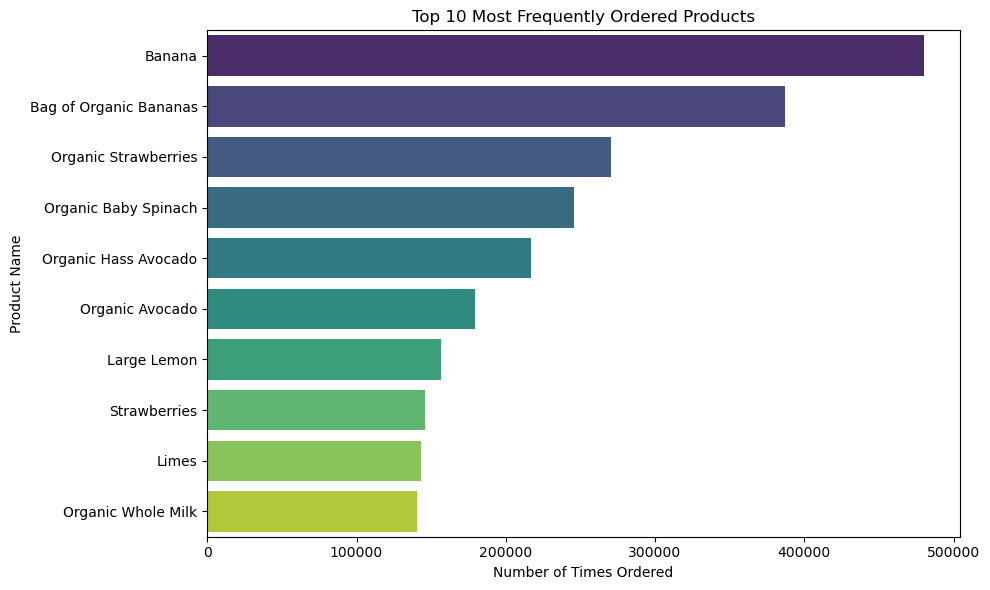

Top 10 products by number of orders:
Banana                         -- ordered 480227 times
Bag of Organic Bananas         -- ordered 387288 times
Organic Strawberries           -- ordered 270529 times
Organic Baby Spinach           -- ordered 245784 times
Organic Hass Avocado           -- ordered 217085 times
Organic Avocado                -- ordered 179304 times
Large Lemon                    -- ordered 156488 times
Strawberries                   -- ordered 145570 times
Limes                          -- ordered 143327 times
Organic Whole Milk             -- ordered 140287 times


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- STEP 1: RELOAD THE DATAFRAME ---
# We force reload 'products' to ensure it is a DataFrame, not a list.
# Using r'' handles the backslashes in your Windows path safely.
products = pd.read_csv(r'E:\Dissertation Sem\Papers for dissertation\products.csv')

# --- STEP 2: COMPUTE FREQUENCY ---
# Calculate order frequency
product_counts = order_products['product_id'].value_counts().reset_index()
product_counts.columns = ['product_id', 'order_count']

# --- STEP 3: MERGE (This will now work) ---
product_counts = product_counts.merge(products[['product_id', 'product_name']], on='product_id', how='left')

# Get top 10
top10_products = product_counts.nlargest(10, 'order_count')

# --- STEP 4: PLOT ---
plt.figure(figsize=(10, 6))
sns.barplot(data=top10_products, x='order_count', y='product_name', palette='viridis')
plt.title('Top 10 Most Frequently Ordered Products')
plt.xlabel('Number of Times Ordered')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

# Print text results
print("Top 10 products by number of orders:")
for _, row in top10_products.iterrows():
    print(f"{str(row['product_name'])[:30]:30} -- ordered {row['order_count']} times")

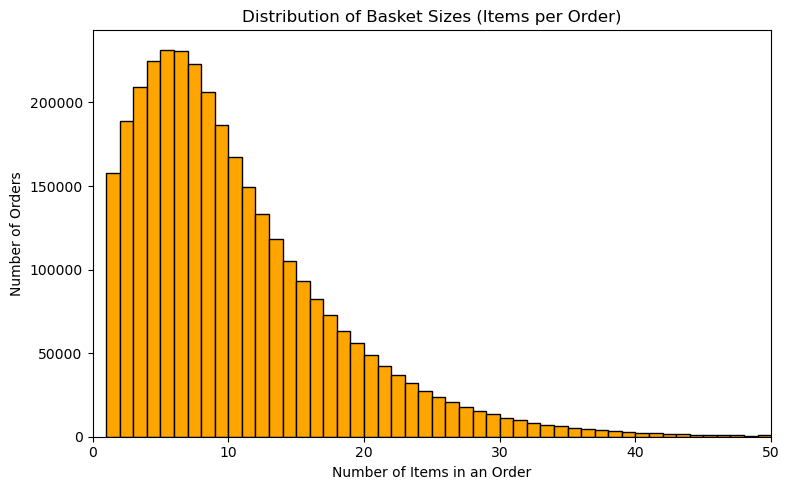

Average basket size: 10.11 items
Median basket size: 8.0 items
Most common basket size (mode): 5 items


In [15]:
# Calculate basket size for each order (number of items per order)
order_sizes = order_products.groupby('order_id').size()  # pandas Series: index=order_id, value= size

# Plot distribution of basket sizes
plt.figure(figsize=(8, 5))
plt.hist(order_sizes, bins=range(1, 51), color='orange', edgecolor='k')  # bins 1 to 50 for readability
plt.title('Distribution of Basket Sizes (Items per Order)')
plt.xlabel('Number of Items in an Order')
plt.ylabel('Number of Orders')
plt.xlim(0,50)  # focus on 0-50 range for clarity
plt.tight_layout()
plt.show()

# Compute and print some statistics on basket sizes
mean_size = order_sizes.mean()
median_size = order_sizes.median()
mode_size = order_sizes.mode()[0]
print(f"Average basket size: {mean_size:.2f} items")
print(f"Median basket size: {median_size} items")
print(f"Most common basket size (mode): {mode_size} items")


Overall, about 59.9% of ordered items are reorders (previously purchased).

Top 5 products by reorder rate (among products with 100+ orders):
Chocolate Love Bar              -  reorder rate: 92.2%
Maca Buttercups                 -  reorder rate: 89.4%
Benchbreak Chardonnay           -  reorder rate: 89.2%
Thousand Island Salad Snax      -  reorder rate: 88.3%
Fragrance Free Clay with Natur  -  reorder rate: 87.0%

Reorder rates by department:
frozen                55.2%
other                 42.2%
bakery                63.8%
produce               66.0%
alcohol               58.5%
international         37.8%
beverages             66.3%
pets                  61.5%
dry goods pasta       47.1%
bulk                  58.4%
personal care         33.3%
meat seafood          57.8%
pantry                35.5%
breakfast             57.1%
canned goods          46.8%
dairy eggs            67.9%
household             41.3%
babies                58.5%
snacks                58.3%
deli                 

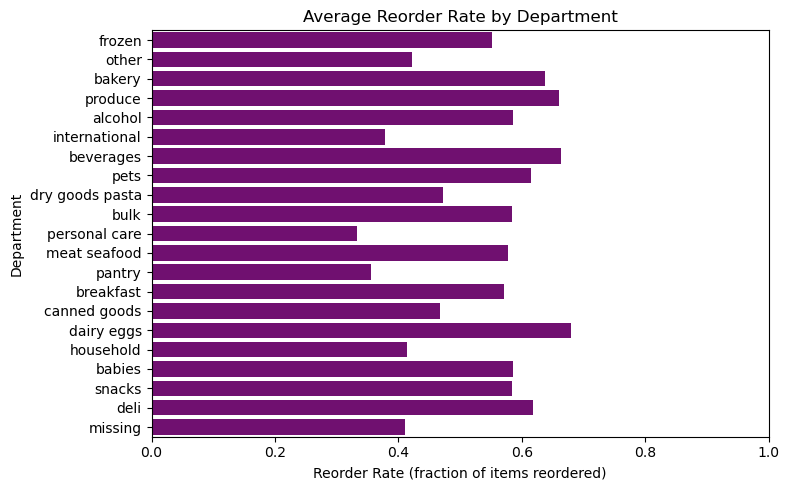

In [17]:
# Overall reorder rate (fraction of items that are reorders)
overall_reorder_rate = order_products['reordered'].mean()
print(f"Overall, about {overall_reorder_rate*100:.1f}% of ordered items are reorders (previously purchased).")

# Reorder rate per product (we will compute and then examine top/bottom examples)
product_reorder_rate = order_products.groupby('product_id')['reordered'].mean()

# Attach product names for interpretability
product_reorder_rate = product_reorder_rate.reset_index().merge(products[['product_id','product_name']], on='product_id')
product_reorder_rate.rename(columns={'reordered':'reorder_rate'}, inplace=True)

# Get the top 5 products with highest reorder rate (min 100 orders to avoid noise)
min_orders = 100
product_counts = order_products['product_id'].value_counts().reset_index()
product_counts.columns = ['product_id', 'count']
prod_reorder_merged = product_reorder_rate.merge(product_counts, on='product_id')
top5_reordered = prod_reorder_merged[prod_reorder_merged['count']>=min_orders].nlargest(5, 'reorder_rate')
print("\nTop 5 products by reorder rate (among products with 100+ orders):")
for _, row in top5_reordered.iterrows():
    print(f"{row['product_name'][:30]:30}  -  reorder rate: {row['reorder_rate']*100:.1f}%")

# Reorder rate by department
# Map each product_id to its department
order_products['department_id'] = order_products['product_id'].map(products.set_index('product_id')['department_id'])
dept_reorder = order_products.groupby('department_id')['reordered'].mean().reset_index()
dept_reorder = dept_reorder.merge(departments, on='department_id')
dept_reorder.rename(columns={'reordered':'reorder_rate','department':'department_name'}, inplace=True)

print("\nReorder rates by department:")
for _, row in dept_reorder.iterrows():
    print(f"{row['department_name']:20}  {row['reorder_rate']*100:.1f}%")

# Plot: Reorder rate by department
plt.figure(figsize=(8,5))
sns.barplot(data=dept_reorder, x='reorder_rate', y='department_name', color='purple')
plt.title('Average Reorder Rate by Department')
plt.xlabel('Reorder Rate (fraction of items reordered)')
plt.ylabel('Department')
plt.xlim(0, 1)  # 0% to 100%
plt.tight_layout()
plt.show()


In [ ]:
# Map day-of-week numbers to names for clarity
dow_map = {0:'Sunday', 1:'Monday', 2:'Tuesday', 3:'Wednesday', 
           4:'Thursday', 5:'Friday', 6:'Saturday'}
orders['order_dow_name'] = orders['order_dow'].map(dow_map)

# Orders by day of week
orders_by_day = orders['order_dow_name'].value_counts().reindex(
    ['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday'])
print("Orders per day of week:")
print(orders_by_day)

plt.figure(figsize=(8,5))
sns.barplot(x=orders_by_day.index, y=orders_by_day.values, palette='Blues_d')
plt.title('Distribution of Orders by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Orders by hour of day
orders_by_hour = orders['order_hour_of_day'].value_counts().sort_index()
print("\nOrders per hour of day:")
print(orders_by_hour.head(5), " ...")  # print first few

plt.figure(figsize=(8,5))
sns.barplot(x=orders_by_hour.index, y=orders_by_hour.values, color='green')
plt.title('Distribution of Orders by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.xticks(range(0,24,2))  # label every 2 hours for readability
plt.tight_layout()
plt.show()


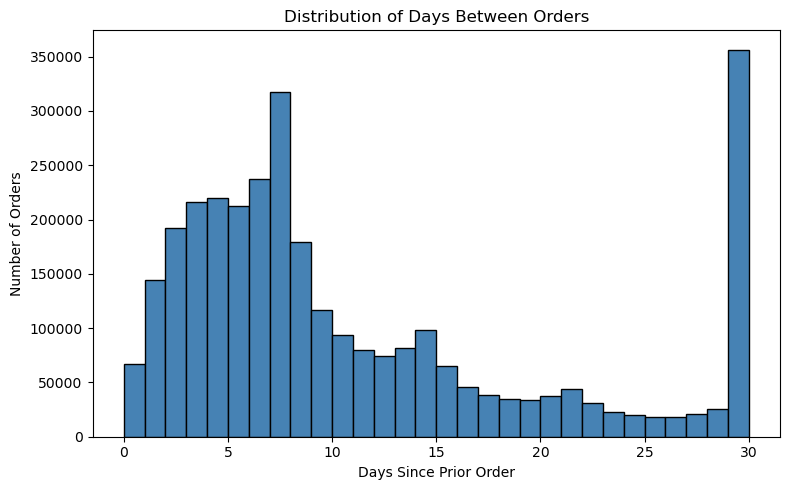

Average days between orders: 10.9
Median days between orders: 7.0


In [19]:
# Distribution of days since prior order
intervals = orders['days_since_prior_order'].dropna()  # drop NaN for first orders
plt.figure(figsize=(8,5))
plt.hist(intervals, bins=30, color='steelblue', edgecolor='k')
plt.title('Distribution of Days Between Orders')
plt.xlabel('Days Since Prior Order')
plt.ylabel('Number of Orders')
plt.xticks(range(0, 31, 5))
plt.tight_layout()
plt.show()

# Calculate some stats on the intervals
mean_interval = intervals.mean()
median_interval = intervals.median()
print(f"Average days between orders: {mean_interval:.1f}")
print(f"Median days between orders: {median_interval}")


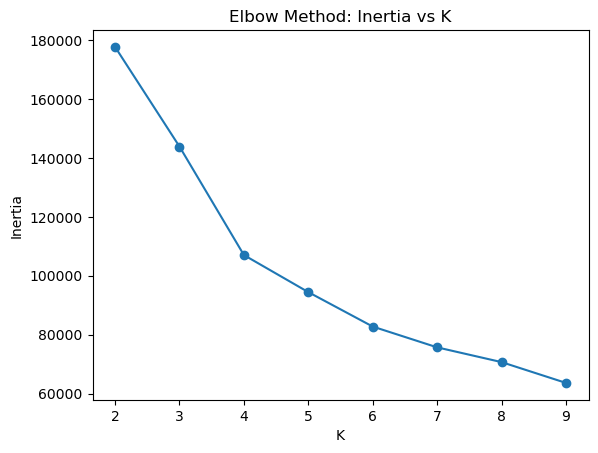

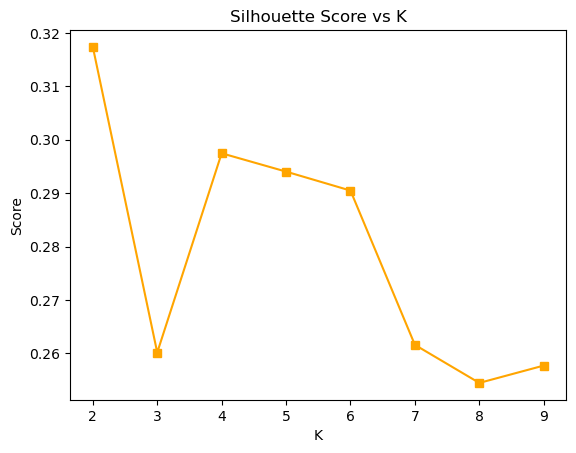

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Select features and scale
X = rfm[['log_frequency', 'avg_days_between_orders', 'avg_basket_size']]
X_scaled = StandardScaler().fit_transform(X)

# Elbow + silhouette score
inertias = []
silhouettes = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Plot Elbow
plt.figure()
plt.plot(K, inertias, marker='o')
plt.title('Elbow Method: Inertia vs K')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.show()

# Plot Silhouette
plt.figure()
plt.plot(K, silhouettes, marker='s', color='orange')
plt.title('Silhouette Score vs K')
plt.xlabel('K')
plt.ylabel('Score')
plt.show()


In [38]:
# Final clustering with selected optimal_k
optimal_k = 4  # selected from the plot
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
rfm['cluster'] = kmeans.fit_predict(X_scaled)

# See how clusters look
rfm.groupby('cluster').agg({
    'frequency': 'mean',
    'avg_days_between_orders': 'mean',
    'avg_basket_size': 'mean',
    'user_id': 'count'
}).rename(columns={'user_id': 'num_customers'})


,frequency,avg_days_between_orders,avg_basket_size,num_customers
cluster,,,,
0,8.075485,20.242109,72.899898,22627
1,6.504256,11.088337,36.164798,22203
2,6.345547,23.175632,29.405430,28138
3,16.000972,12.535177,69.076022,18521


Association Rule Modelling

Pre-Process basket data

In [41]:
# Sample 5000 recent orders
sample_orders = order_products['order_id'].drop_duplicates().sample(5000, random_state=42)
sample_df = order_products[order_products['order_id'].isin(sample_orders)]

# Build basket matrix on this subset
basket = sample_df.groupby(['order_id', 'product_name'])['product_id'].count().unstack().fillna(0)
basket = basket.applymap(lambda x: 1 if x > 0 else 0)
basket.head()

C:\Users\AAKRITI GOYAL\AppData\Local\Temp\ipykernel_7852\357793963.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(lambda x: 1 if x > 0 else 0)


product_name,#2 Coffee Filters,#2 Cone White Coffee Filters,0 Calorie Acai Raspberry Water Beverage,0% Fat Free Organic Milk,0% Fat Organic Greek Vanilla Yogurt,0% Fat Superfruits Greek Yogurt,0% Greek Strained Yogurt,0% Greek Yogurt Black Cherry on the Bottom,"0% Greek, Blueberry on the Bottom Yogurt",0% Milkfat Greek Plain Yogurt,...,for Tots Apple Juice,in Gravy with Carrots Peas & Corn Mashed Potatoes & Meatloaf Nuggets,of Hanover 100 Calorie Pretzels Mini,of Norwich Original English Mustard Powder Double Superfine,smartwater® Electrolyte Enhanced Water,vitaminwater® XXX Acai Blueberry Pomegranate,with Crispy Almonds Cereal,with Olive Oil Mayonnaise Dressing,with Xylitol Cinnamon 18 Sticks Sugar Free Gum,with Xylitol Watermelon Twist 18 Sticks Sugar Free Gum
order_id,,,,,,,,,,,,,,,,,,,,,
477,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1342,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1543,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1966,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2171,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Generate Frequent Itemsets

In [43]:
!pip install mlxtend

In [44]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(basket, min_support=0.01, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)
frequent_itemsets.head(10)


E:\anaconda\envs\nbo_env\lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
6,0.1478,(Banana)
5,0.1200,(Bag of Organic Bananas)
78,0.0830,(Organic Strawberries)
39,0.0820,(Organic Baby Spinach)
61,0.0704,(Organic Hass Avocado)
35,0.0526,(Organic Avocado)
30,0.0520,(Large Lemon)
69,0.0454,(Organic Raspberries)
100,0.0440,(Strawberries)
32,0.0438,(Limes)


Generate Association rules

In [46]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
rules = rules[(rules['confidence'] >= 0.3) & (rules['lift'] >= 1.2)]

rules.sort_values(by='lift', ascending=False).head(10)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
29,(Organic Blueberries),(Organic Strawberries),0.0352,0.0830,0.0106,0.301136,3.628149,1.0,0.007678,1.312130,0.750806,0.098513,0.237880,0.214424
14,(Organic Raspberries),(Bag of Organic Bananas),0.0454,0.1200,0.0146,0.321586,2.679883,1.0,0.009152,1.297143,0.656662,0.096817,0.229075,0.221626
17,(Strawberries),(Banana),0.0440,0.1478,0.0146,0.331818,2.245049,1.0,0.008097,1.275401,0.580100,0.082393,0.215933,0.215300
7,(Organic Avocado),(Banana),0.0526,0.1478,0.0172,0.326996,2.212424,1.0,0.009426,1.266263,0.578433,0.093886,0.210275,0.221685


NBO Function

In [48]:
def recommend_next(basket_products, rules_df, top_n=3):
    """
    Given a list of products in a user's basket, return top N recommended products.
    """
    basket_set = set(basket_products)

    # Match rules where basket is a superset of the antecedents
    matched = rules_df[rules_df['antecedents'].apply(lambda x: x.issubset(basket_set))]

    # Sort by lift and confidence
    matched = matched.sort_values(by=['lift', 'confidence'], ascending=False)

    # Collect consequents
    recommended = matched['consequents'].explode().value_counts().head(top_n)
    return list(recommended.index)


In [49]:
recommend_next(['Organic Avocado', 'Organic Blueberries'], rules)


['Organic Strawberries', 'Banana']

In [60]:
print(rules[['antecedents', 'consequents']].head())


              antecedents               consequents
7       (Organic Avocado)                  (Banana)
14  (Organic Raspberries)  (Bag of Organic Bananas)
17         (Strawberries)                  (Banana)
29  (Organic Blueberries)    (Organic Strawberries)


In [62]:
from sklearn.metrics import precision_score, recall_score, f1_score
from collections import Counter
import numpy as np

# Make sure antecedents and consequents are sets
rules['antecedents'] = rules['antecedents'].apply(lambda x: set(x) if isinstance(x, (set, frozenset)) else set([x]))
rules['consequents'] = rules['consequents'].apply(lambda x: set(x) if isinstance(x, (set, frozenset)) else set([x]))

# Generate test baskets (last basket prediction setup)
test_baskets = []
actual_next_items = []

for user, seq in user_sequences.items():
    if len(seq) > 3:
        test_baskets.append(seq[:-1])  # prior purchases
        actual_next_items.append(seq[-1])  # next item

# Filter baskets that match at least one rule
y_true, y_pred = [], []
for basket, true_item in zip(test_baskets, actual_next_items):
    preds = recommend_next(basket, rules, top_n=1)
    if preds:
        y_true.append(true_item)
        y_pred.append(preds[0])

# Encode predictions using LabelEncoder for comparison
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
encoder.fit(y_true + y_pred)
y_true_enc = encoder.transform(y_true)
y_pred_enc = encoder.transform(y_pred)

# Metrics
precision = precision_score(y_true_enc, y_pred_enc, average='macro', zero_division=0)
recall = recall_score(y_true_enc, y_pred_enc, average='macro', zero_division=0)
f1 = f1_score(y_true_enc, y_pred_enc, average='macro', zero_division=0)
accuracy = np.mean(np.array(y_true_enc) == np.array(y_pred_enc))

print(f"Top-1 Accuracy (Apriori): {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")


Top-1 Accuracy (Apriori): nan
Precision: nan
Recall:    nan
F1 Score:  nan


E:\anaconda\envs\nbo_env\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
E:\anaconda\envs\nbo_env\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [25]:
import pandas as pd

products = pd.read_csv("E:/Dissertation Sem/Papers for dissertation/products.csv")


Visualizations for Model 1

In [ ]:
!pip install seaborn

C:\Users\AAKRITI GOYAL\AppData\Local\Temp\ipykernel_10108\1840249624.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='lift', y='rule', data=top_rules, palette='viridis')


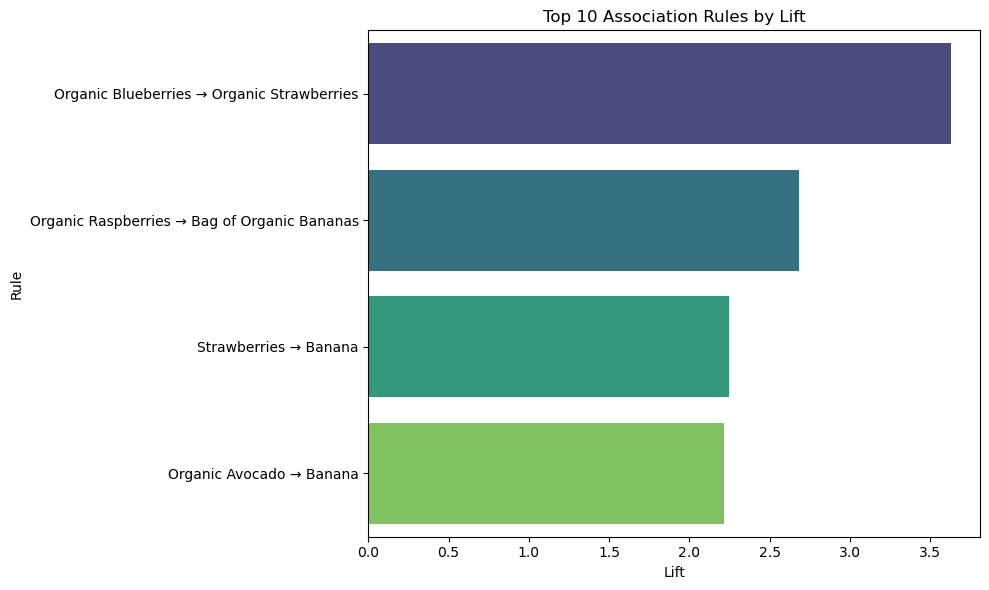

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare top N rules
top_rules = rules.sort_values(by='lift', ascending=False).head(10).copy()
top_rules['rule'] = top_rules['antecedents'].apply(lambda x: ', '.join(x)) + ' → ' + \
                    top_rules['consequents'].apply(lambda x: ', '.join(x))

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='lift', y='rule', data=top_rules, palette='viridis')
plt.title('Top 10 Association Rules by Lift')
plt.xlabel('Lift')
plt.ylabel('Rule')
plt.tight_layout()
plt.show()


In [ ]:
!pip install networkx


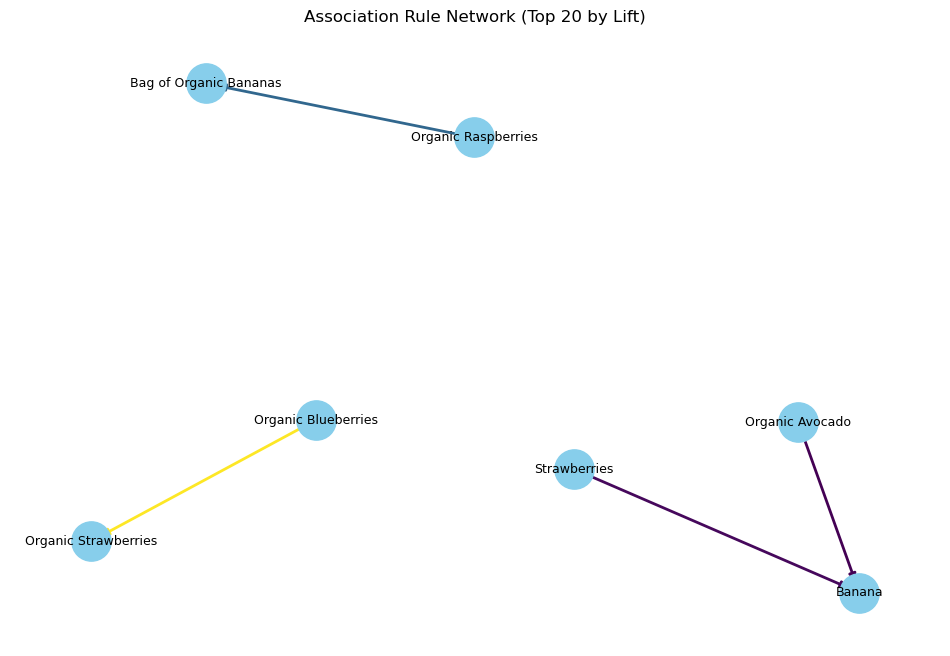

In [44]:
import networkx as nx

# Limiting to top 20 rules to avoid clutter
graph_rules = rules.sort_values(by='lift', ascending=False).head(20)

G = nx.DiGraph()

# Add nodes and edges from rules
for _, row in graph_rules.iterrows():
    for antecedent in row['antecedents']:
        for consequent in row['consequents']:
            G.add_edge(antecedent, consequent, weight=row['lift'], confidence=row['confidence'])

# Draw
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.8)

edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]

nx.draw_networkx_nodes(G, pos, node_size=800, node_color='skyblue')
nx.draw_networkx_labels(G, pos, font_size=9)
nx.draw_networkx_edges(G, pos, edgelist=edges, width=2, edge_color=weights, edge_cmap=plt.cm.viridis)

plt.title("Association Rule Network (Top 20 by Lift)")
plt.axis('off')
plt.show()


Model 2 LSTM

In [9]:
# Sort data by user and order
order_products_seq = order_products.sort_values(by=['user_id', 'order_number'])

# Create purchase history per user
user_sequences = order_products_seq.groupby('user_id')['product_id'].apply(list)

# Filter users with enough data
user_sequences = user_sequences[user_sequences.apply(len) >= 5]

# Flatten into (X_seq, y) pairs
sequence_data = []
seq_len = 3  # you can tune this

for user, products in user_sequences.items():
    for i in range(seq_len, len(products)):
        X_seq = products[i-seq_len:i]
        y = products[i]
        sequence_data.append((X_seq, y))

print("Total sequences:", len(sequence_data))


Total sequences: 32394096


Encode Product IDs

We need to convert product IDs into contiguous integer indices and later into one-hot or embedding format.

In [10]:
from sklearn.preprocessing import LabelEncoder

# Flatten sequences and targets
X_seq_all, y_all = zip(*sequence_data)

# Fit encoder on all product IDs
product_encoder = LabelEncoder()
product_encoder.fit([pid for seq in X_seq_all for pid in seq] + list(y_all))

# Flatten all sequences into a single 1D list
flattened_X = [pid for seq in X_seq_all for pid in seq]
X_flat_encoded = product_encoder.transform(flattened_X)


# Reshape back into original (n_sequences, seq_len)
X_encoded = X_flat_encoded.reshape(-1, 3)

# Encode targets
y_encoded = product_encoder.transform(y_all)

vocab_size = len(product_encoder.classes_)
print("Unique products:", vocab_size)


Unique products: 42631


In [ ]:
!pip install tensorflow

In [11]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import numpy as np

# Pad input sequences to fixed length
X_padded = pad_sequences(X_encoded, maxlen=3, padding='pre')  # already fixed-length, but standardizes shape

# Convert to NumPy
X_np = np.array(X_padded)
y_np = np.array(y_encoded)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_np, y_np, test_size=0.2, random_state=42)

print("Train samples:", len(X_train), "Test samples:", len(X_test))


Train samples: 25915276 Test samples: 6478820


Training the LSTM Model

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.optimizers import Adam

model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=64, input_length=3))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(vocab_size, activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
model.summary()


E:\anaconda\envs\nbo_env\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.fit(
    X_train[:500_000], 
    y_train[:500_000], 
    epochs=3, 
    batch_size=256, 
    validation_split=0.1
)


Epoch 1/3
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 433s 245ms/step - accuracy: 0.0139 - loss: 8.9693 - val_accuracy: 0.0141 - val_loss: 8.4232
Epoch 2/3
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 406s 231ms/step - accuracy: 0.0146 - loss: 8.2699 - val_accuracy: 0.0158 - val_loss: 8.2874
Epoch 3/3
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 372s 212ms/step - accuracy: 0.0163 - loss: 8.0788 - val_accuracy: 0.0175 - val_loss: 8.2311


Evaluating LSTM Model

In [14]:
# Predict probabilities
y_probs = model.predict(X_test[:5])

# Get top predicted product for each sequence
y_pred_ids = np.argmax(y_probs, axis=1)

# Decode product names
predicted_products = product_encoder.inverse_transform(y_pred_ids)
true_products = product_encoder.inverse_transform(y_test[:5])

for i in range(5):
    print(f"Input Sequence: {product_encoder.inverse_transform(X_test[i])}")
    print(f"Predicted NBO: {predicted_products[i]}")
    print(f"Actual Next:    {true_products[i]}")
    print("—" * 40)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step
Input Sequence: [26209  5652 14197]
Predicted NBO: 24852
Actual Next:    13510
————————————————————————————————————————
Input Sequence: [22695  5876 37849]
Predicted NBO: 24852
Actual Next:    14651
————————————————————————————————————————
Input Sequence: [42659 30146 27156]
Predicted NBO: 13176
Actual Next:    29117
————————————————————————————————————————
Input Sequence: [43698 44879  5025]
Predicted NBO: 24852
Actual Next:    21405
————————————————————————————————————————
Input Sequence: [26604 18523  4957]
Predicted NBO: 13176
Actual Next:    40571
————————————————————————————————————————


In [15]:
import numpy as np

# Predict probabilities
y_pred_probs = model.predict(X_test[:1000])

# Top-K predictions manually
k = 5
top_k_preds = np.argsort(y_pred_probs, axis=1)[:, -k:]

# Count how often true label appears in top-k
y_true_subset = y_test[:1000]
correct = sum(y in preds for y, preds in zip(y_true_subset, top_k_preds))

top_k_accuracy = correct / len(y_true_subset)
print(f"Top-{k} Accuracy: {top_k_accuracy:.4f}")





32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Top-5 Accuracy: 0.0430


In [16]:
# Construct user-level final order test set
SEQ_LEN = 3
X_test_eval = []
y_test_eval = []

for user, seq in user_sequences.items():
    if len(seq) < SEQ_LEN + 1:
        continue
    last_seq = seq[-(SEQ_LEN + 1):]
    X_test_eval.append(last_seq[:-1])
    y_test_eval.append(last_seq[-1])

# Encode using LabelEncoder
X_test_encoded = [product_encoder.transform(seq) for seq in X_test_eval]
y_test_encoded = product_encoder.transform(y_test_eval)

# Reduced samples
X_test_final_small = X_test[:1000]
y_test_final_small = y_test[:1000]

# Now predict
y_pred_probs = model.predict(X_test_final_small, batch_size=64)
y_pred_top1 = np.argmax(y_pred_probs, axis=1)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [17]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Basic metrics
accuracy = accuracy_score(y_test_final_small, y_pred_top1)
precision = precision_score(y_test_final_small, y_pred_top1, average='macro', zero_division=0)
recall = recall_score(y_test_final_small, y_pred_top1, average='macro', zero_division=0)
f1 = f1_score(y_test_final_small, y_pred_top1, average='macro', zero_division=0)

print(f"Top-1 Accuracy:  {accuracy:.4f}")
print(f"Precision:       {precision:.4f}")
print(f"Recall:          {recall:.4f}")
print(f"F1 Score:        {f1:.4f}")


Top-1 Accuracy:  0.0120
Precision:       0.0001
Recall:          0.0025
F1 Score:        0.0003


Evaluating Apriori

In [43]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from collections import Counter

MAX_TRANSACTIONS = 500_00
TOP_PRODUCTS = 1000         # Keep only top-N most frequent products

# === STEP 1: Load and Preprocess ===
products = pd.read_csv("E:/Dissertation Sem/Papers for dissertation/products.csv")
order_prior = pd.read_csv("E:/Dissertation Sem/Papers for dissertation/order_products__prior.csv")
orders = pd.read_csv("E:/Dissertation Sem/Papers for dissertation/orders.csv")

# Filter for prior orders only
orders = orders[orders['eval_set'] == 'prior']
order_data = order_prior.merge(orders[['order_id', 'user_id']], on='order_id')

# Map product_id to product_name
product_map = products.set_index('product_id')['product_name'].to_dict()
order_data['product_name'] = order_data['product_id'].map(product_map)

all_products_flat = [item for basket in transactions for item in basket]
top_items = set([item for item, _ in Counter(all_products_flat).most_common(TOP_PRODUCTS)])

filtered_txns = [
    [item for item in basket if item in top_items]
    for basket in transactions[:MAX_TRANSACTIONS]
    if any(item in top_items for item in basket)
]

print(f"Using {len(filtered_txns)} transactions with top {TOP_PRODUCTS} products")

# === STEP 2: Encode
te = TransactionEncoder()
te_matrix = te.fit(filtered_txns).transform(filtered_txns)
basket_df = pd.DataFrame(te_matrix, columns=te.columns_)

# === STEP 3: Apriori
freq_itemsets = apriori(basket_df, min_support=0.01, use_colnames=True)
rules = association_rules(freq_itemsets, metric="confidence", min_threshold=0.3)
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())

# Ensure antecedents/consequents are sets
rules['antecedents'] = rules['antecedents'].apply(lambda x: set(x))
rules['consequents'] = rules['consequents'].apply(lambda x: set(x))

# === STEP 4: Evaluation on Simulated Test Set ===
user_sequences = order_data.groupby('user_id')['product_name'].apply(list).to_dict()
SEQ_LEN = 3
test_baskets = []
actual_next_items = []

for user, seq in user_sequences.items():
    if len(seq) > SEQ_LEN:
        test_baskets.append(seq[:-1])
        actual_next_items.append(seq[-1])

# === STEP 5: Prediction Function ===
def recommend_next(basket_products, rules_df, top_n=3):
    basket_set = set(basket_products)
    matched = rules_df[rules_df['antecedents'].apply(lambda x: x.issubset(basket_set))]
    matched = matched.sort_values(by=['lift', 'confidence'], ascending=False)
    recommended = matched['consequents'].explode().value_counts().head(top_n)
    return list(recommended.index)

# === STEP 6: Evaluate Predictions ===
y_pred = []
y_true = []

for basket, true in zip(test_baskets, actual_next_items):
    preds = recommend_next(basket, rules, top_n=1)
    if preds:
        y_pred.append(preds[0])
        y_true.append(true)

# Convert to NumPy arrays
if y_pred:
    y_pred = np.array(y_pred)
    y_true = np.array(y_true)

    accuracy = np.mean(y_true == y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f"Top-1 Accuracy (Apriori): {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
else:
    print("No valid predictions made. Evaluation skipped.")


Using 46000 transactions with top 1000 products
             antecedents               consequents   support  confidence  \
0  (Organic Raspberries)  (Bag of Organic Bananas)  0.014565    0.305378   
1       (Cucumber Kirby)                  (Banana)  0.011000    0.331152   
2      (Organic Avocado)                  (Banana)  0.018217    0.307862   
3   (Organic Fuji Apple)                  (Banana)  0.011174    0.361972   

       lift  
0  2.354971  
1  2.052410  
2  1.908063  
3  2.243426  
Top-1 Accuracy (Apriori): 0.0115
Precision: 0.0000
Recall:    0.0001
F1 Score:  0.0000
